## baseline 只扫描gain，固定其他3个

In [1]:
import time
import numpy as np
import os
import sys

# 将目录添加到 Python 路径
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO')
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO/tutorials/scao_system/myAoSystem')
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.ShackHartmann import ShackHartmann
from tutorials.scao_system.myAoSystem.Imager_new import Imager_new  # 导入新的科学相机模块
from tutorials.scao_system.myAoSystem.Imager import Imager # 导入之前的的科学相机模块
import matplotlib.pyplot as plt
import OOPAO.tools.displayTools as tools
import importlib
from OOPAO.calibration.ao_calibration import ao_calibration
def load_parameter_file(file_name):
    """动态加载指定参数文件"""
    try:
        module = importlib.import_module(f'envs.paramsettings.{file_name}')
        return module.initializeParameterFile()
    except ImportError:
        raise ValueError(f"参数文件 {file_name} 不存在")



     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2


In [2]:
def run_baseline(paramFile='',frames=500):
    param = load_parameter_file(paramFile)
    param['samplingRate'] = 1000
    param['exposureTime'] = 1
    param['clockRate'] = 1000
    tel = Telescope(resolution         =   param['resolution'], 
                        diameter           =   param['diameter'], 
                        samplingTime       =   1/param['samplingRate'], 
                        centralObstruction =   param['centralObstruction'])

    ngs = Source(magnitude             =   param['magnitude'],
                        optBand               =   param['opticalBand'])
    ngs * tel
    atm = Atmosphere(telescope         =   tel, 
                            r0                =   param['r0'], 
                            L0                =   param['L0'], 
                            windSpeed         =   param['windSpeed'],
                            fractionalR0      =   param['fractionnalR0'], 
                            windDirection     =   param['windDirection'],
                            altitude          =   param['altitude'])

    dm = DeformableMirror(telescope    =   tel, 
                                nSubap       =   param['nSubap'], 
                                mechCoupling =   param['mechCoupling'])

    wfs = ShackHartmann(nSubap         =   param['nSubap'], 
                                telescope      =   tel, 
                                lightRatio     =   param['lightRatio'], 
                                is_geometric   =   param['is_geometric'], 
                                threshold_cog  =   param['threshold_cog'])


    camH = Imager(exposure_time=param['exposureTime'], 
                        clock_rate=param['clockRate'],
                        nyquist_sampling=param['nyquist_sampling'],
                        field_stop_size=param['field_stop_size'])
    
    ao_calib = ao_calibration(param=param, \
                                ngs=ngs, \
                                tel=tel, \
                                atm=atm, \
                                dm=dm, \
                                wfs=wfs, \
                                nameFolderIntMat=None, \
                                nameIntMat=None, \
                                nameFolderBasis=None, \
                                nameBasis=None, \
                                nMeasurements=100)
    calib_CL = ao_calib.calib  # 交互矩阵
    M2C_CL = ao_calib.M2C
    wfs.cam.photonNoise                =   param['photonNoise']
    wfs.cam.readoutNoise               =   param['readoutNoise']
    wfs.cam.darkCurrent                =   param['darkCurrent']

    def run(frames=500,gainCL=0.1):
        atm.initializeAtmosphere(telescope=tel)
        dm.coefs = 0
        tel-atm
        ngs * tel * dm * wfs
        camH.relay(tel.src)
        camH.reference_frame = camH.frame
        
        actual_SR  = np.zeros(frames)
        SR_old = np.zeros(frames)
        residual = np.zeros(frames)
        dm.coefs = 0
        wfsSignal = np.zeros(wfs.nSignal)
        for current_step in range(frames):
            # 更新大气湍流相位屏
            atm.update()
            tel-atm
            camH.relay(tel.src)
            camH.reference_frame = camH.frame
            tel+atm

            # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 波前传感器
            ngs * tel * dm * wfs

            
            # # 存入队列
            # wfs_buffer.append(wfsSignal)

            # # 取出延迟后的信号
            # delayed_signal = wfs_buffer[0]
            # # 更新变形镜控制信号
            # dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ delayed_signal
            dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ wfsSignal
            wfsSignal = wfs.signal.copy()


            camH.relay(tel.src)
            SR_old[current_step]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))
            # 计算斯特列尔比（基于科学相机的PSF）
            actual_SR[current_step] = camH.strehl
            residual[current_step]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9

        SR_mean = np.mean(actual_SR)
        SR_std  = np.std(actual_SR[10:])
        WFE = np.mean(residual)
        print(wfs.cam.photonNoise)
        return SR_mean, SR_std, WFE
    
    gains = np.arange(0.05, 1.05, 0.05)

    SR_mean_list = []
    SR_std_list  = []
    WFE_list     = []

    for g in gains:
        print(f"Running gain = {g:.2f}")
        SR_mean, SR_std, WFE = run(frames=frames, gainCL=g)
        SR_mean_list.append(SR_mean)
        SR_std_list.append(SR_std)
        WFE_list.append(WFE)
        print(f"Running gain = {g:.2f},SR_mean = {SR_mean:.4f},SR_std = {SR_std:.4f},WFE = {WFE:.2f}")

    plt.figure(figsize=(8, 6))
    plt.plot(gains, SR_mean_list, '-o', color='tab:blue')
    plt.xlabel('Gain')
    plt.ylabel('SR Mean')
    plt.title('Mean Strehl Ratio vs Gain')
    plt.grid(True)

    plt.figure(figsize=(8, 6))
    plt.plot(gains, SR_std_list, '-o', color='tab:orange')
    plt.xlabel('Gain')
    plt.ylabel('SR Std')
    plt.title('SR Stability vs Gain')
    plt.grid(True)

    plt.figure(figsize=(8, 6))
    plt.plot(gains, WFE_list, '-o', color='tab:green')
    plt.xlabel('Gain')
    plt.ylabel('WFE (nm RMS)')
    plt.title('Residual WFE vs Gain')
    plt.grid(True)

    plt.show()



%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:11<01:30, 11.25s/it]

100/856
Time elapsed: 11.254846096038818 s


 22%|██▏       | 2/9 [00:23<01:23, 11.92s/it]

200/856
Time elapsed: 12.37641978263855 s


...

 89%|████████▉ | 8/9 [01:30<00:11, 11.00s/it]

800/856
Time elapsed: 11.071353435516357 s


100%|██████████| 9/9 [01:37<00:00, 10.81s/it]

900/856
Time elapsed: 6.457614183425903 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.022767305374145508 s
ZZt.. : 14.215973854064941 s
ZXt.. : 0.6044399738311768 s
XXt.. : 0.3239715099334717 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.02218174934387207 s
ZZt.. : 1.430511474609375e-06 s
ZXt.. : 3.075599670410156e-05 s
XXt.. : 7.3909759521484375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.02351236343383789 s
ZZt.. : 4.291534423828125e-06 s
ZXt.. : 4.482269287109375e-05 s
XXt.. : 7.62939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.0914,SR_std = 0.0389,WFE = 261.63
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.1758,SR_std = 0.0537,WFE = 186.91
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.2918,SR_std = 0.0538,WFE = 151.69

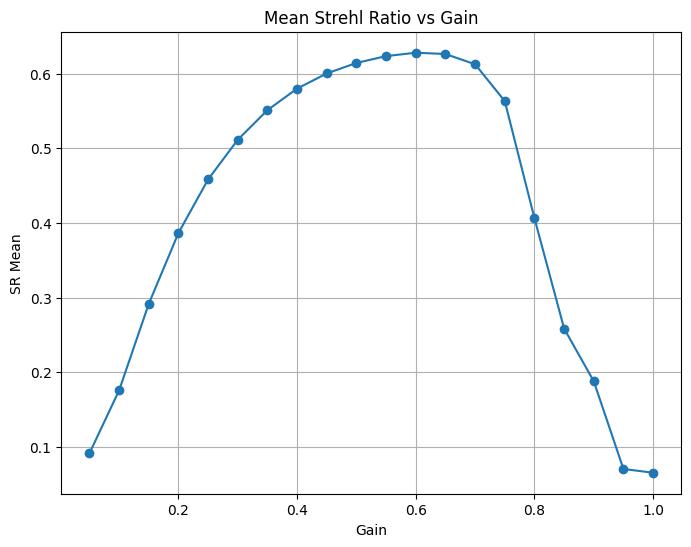

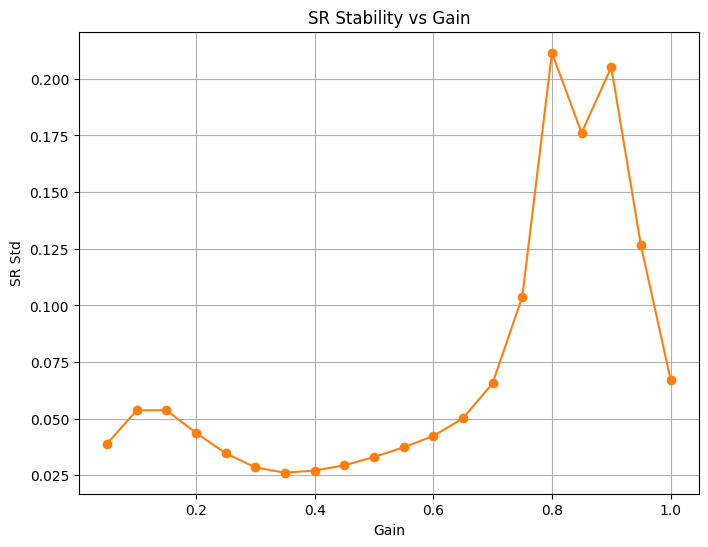

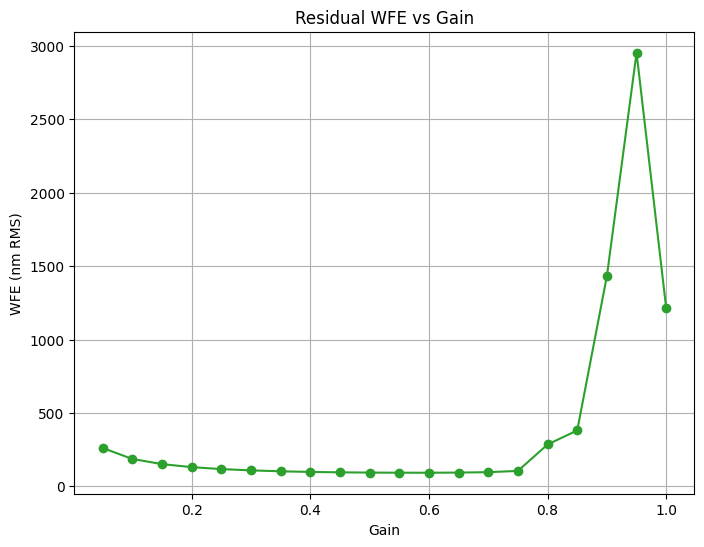

In [3]:
run_baseline(paramFile='1-1',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

  0%|          | 0/9 [00:00<?, ?it/s]

 11%|█         | 1/9 [00:09<01:12,  9.04s/it]

100/856
Time elapsed: 9.039659023284912 s


 22%|██▏       | 2/9 [00:17<01:00,  8.69s/it]

...

 89%|████████▉ | 8/9 [01:08<00:08,  8.48s/it]

800/856
Time elapsed: 8.468488216400146 s


100%|██████████| 9/9 [01:13<00:00,  8.14s/it]

900/856
Time elapsed: 4.981843948364258 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.02554488182067871 s
ZZt.. : 12.628814220428467 s
ZXt.. : 0.5838072299957275 s
XXt.. : 0.29295897483825684 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.02401900291442871 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 3.123283386230469e-05 s
XXt.. : 6.9141387939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.019849300384521484 s
ZZt.. : 1.430511474609375e-06 s
ZXt.. : 4.00543212890625e-05 s
XXt.. : 6.9141387939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.0915,SR_std = 0.0395,WFE = 245.48
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.2098,SR_std = 0.0573,WFE = 175.58
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.3350,SR_std = 0.0609,WFE = 14

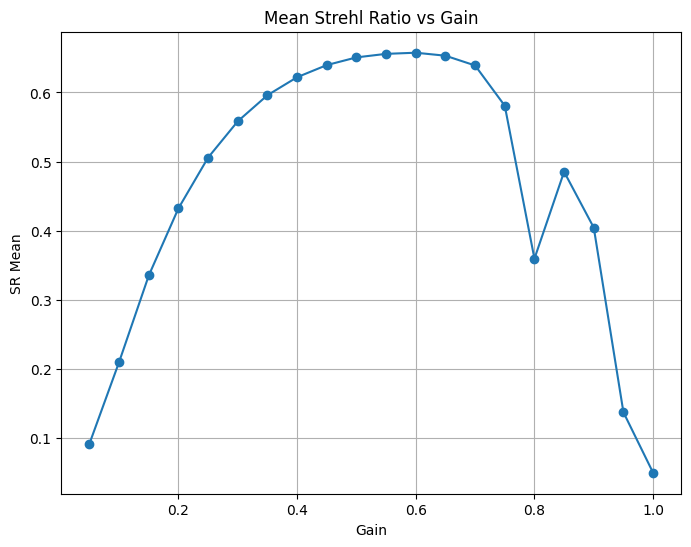

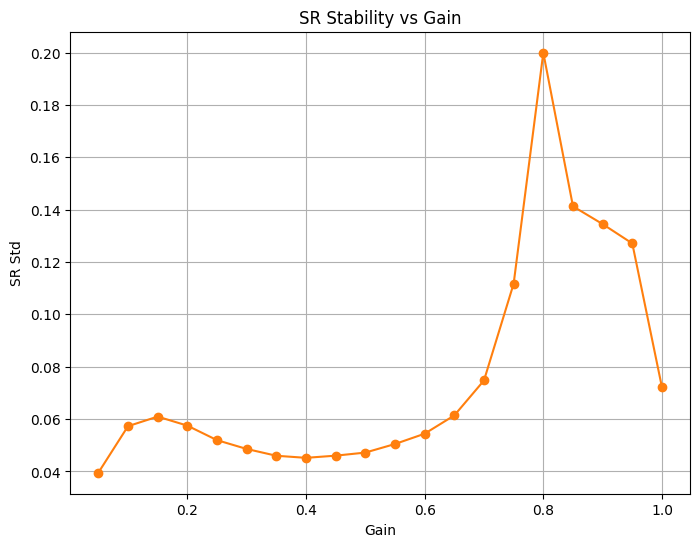

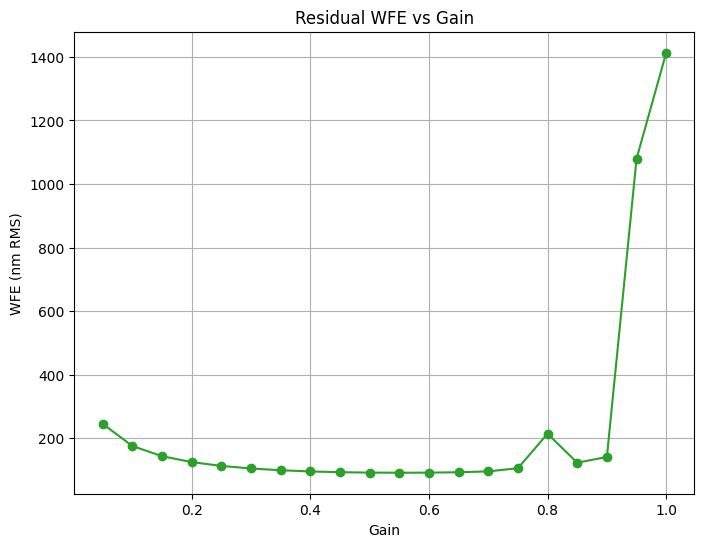

In [4]:
run_baseline(paramFile='1-2',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:16<02:08, 16.02s/it]

100/856
Time elapsed: 16.020591497421265 s


 22%|██▏       | 2/9 [00:28<01:38, 14.00s/it]

200/856
Time elapsed: 12.585214614868164 s


...

 89%|████████▉ | 8/9 [01:50<00:12, 12.70s/it]

800/856
Time elapsed: 11.306636095046997 s


100%|██████████| 9/9 [01:57<00:00, 13.05s/it]

900/856
Time elapsed: 7.382044553756714 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.04873490333557129 s
ZZt.. : 16.77824091911316 s
ZXt.. : 0.6103136539459229 s
XXt.. : 0.3222320079803467 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.024828195571899414 s
ZZt.. : 7.152557373046875e-07 s
ZXt.. : 3.600120544433594e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.04341626167297363 s
ZZt.. : 1.430511474609375e-06 s
ZXt.. : 4.267692565917969e-05 s
XXt.. : 8.58306884765625e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.0874,SR_std = 0.0327,WFE = 306.89
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.1766,SR_std = 0.0611,WFE = 206.41
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.2833,SR_std = 0.0854,WFE = 162.4

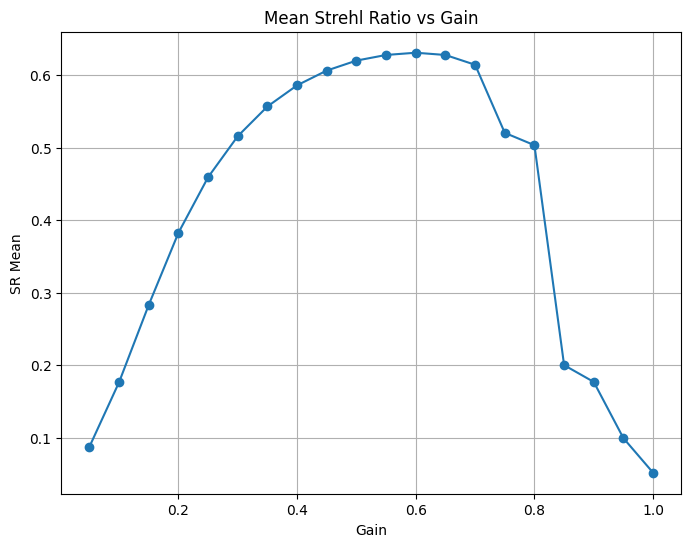

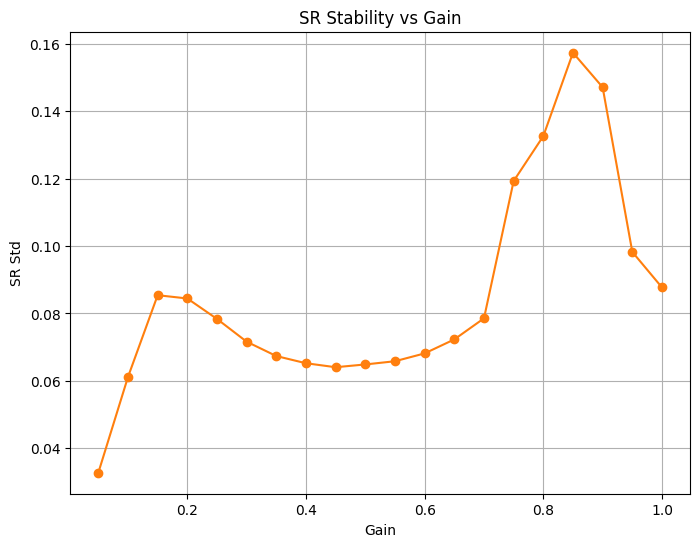

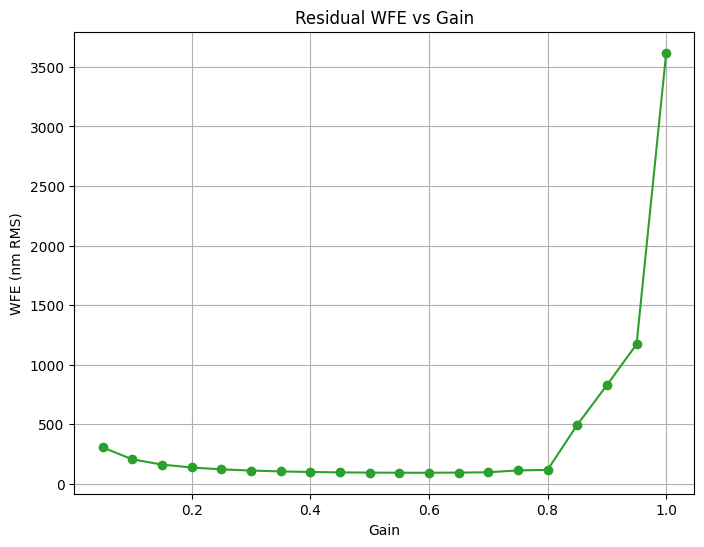

In [5]:
run_baseline(paramFile='1-3',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:18<02:27, 18.38s/it]

100/856
Time elapsed: 18.37827181816101 s


 22%|██▏       | 2/9 [00:33<01:53, 16.23s/it]

200/856
Time elapsed: 14.723410844802856 s


...

 89%|████████▉ | 8/9 [01:44<00:12, 12.14s/it]

800/856
Time elapsed: 12.930835485458374 s


100%|██████████| 9/9 [01:50<00:00, 12.30s/it]

900/856
Time elapsed: 6.129240274429321 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.028154373168945312 s
ZZt.. : 22.684495449066162 s
ZXt.. : 0.9127490520477295 s
XXt.. : 0.45517420768737793 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.04539942741394043 s
ZZt.. : 1.6689300537109375e-06 s
ZXt.. : 5.7220458984375e-05 s
XXt.. : 9.5367431640625e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.03621387481689453 s
ZZt.. : 9.5367431640625e-07 s
ZXt.. : 4.506111145019531e-05 s
XXt.. : 1.0013580322265625e-05 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.1073,SR_std = 0.0322,WFE = 235.93
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.2467,SR_std = 0.0528,WFE = 163.12
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.3845,SR_std = 0.0441,WFE = 131.18

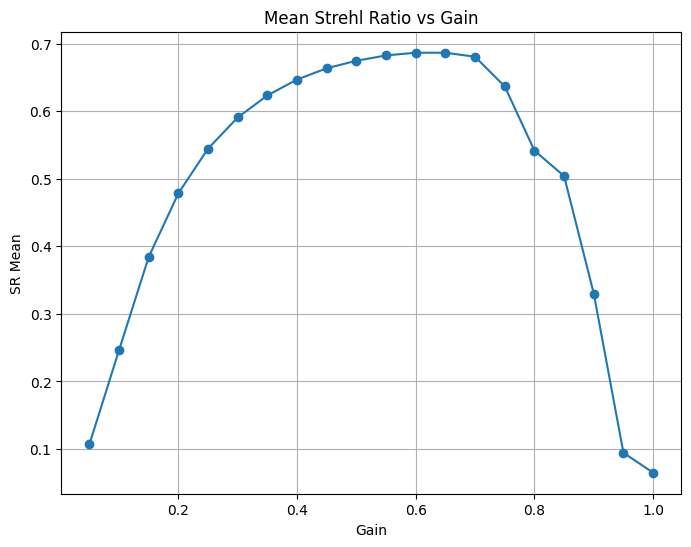

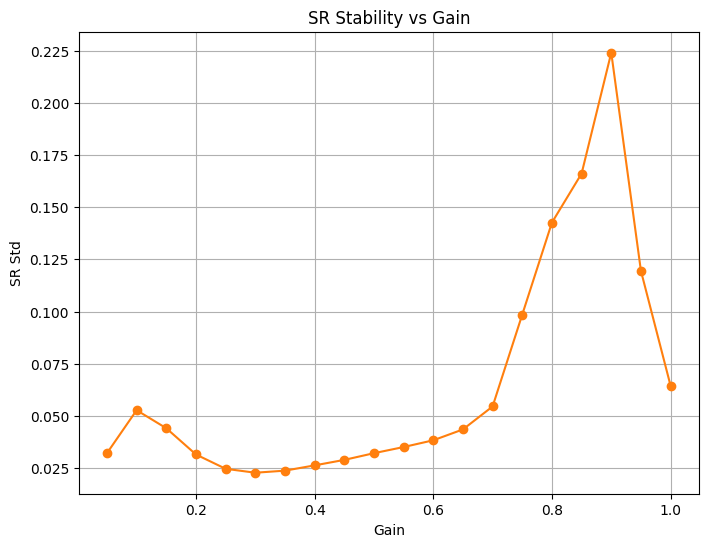

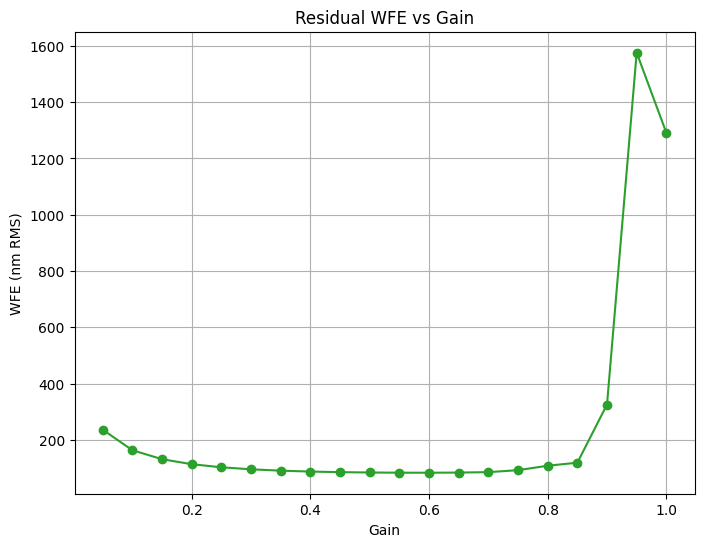

In [6]:
run_baseline(paramFile='2-1',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:17<02:22, 17.86s/it]

100/856
Time elapsed: 17.862624645233154 s


 22%|██▏       | 2/9 [00:29<01:40, 14.41s/it]

200/856
Time elapsed: 11.985222578048706 s


...

 89%|████████▉ | 8/9 [01:46<00:13, 13.18s/it]

800/856
Time elapsed: 13.901420831680298 s


100%|██████████| 9/9 [01:54<00:00, 12.75s/it]

900/856
Time elapsed: 8.144038438796997 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.025252819061279297 s
ZZt.. : 19.477054357528687 s
ZXt.. : 0.8667953014373779 s
XXt.. : 0.47429752349853516 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.048111677169799805 s
ZZt.. : 9.5367431640625e-07 s
ZXt.. : 4.0531158447265625e-05 s
XXt.. : 9.5367431640625e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.04905056953430176 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 5.793571472167969e-05 s
XXt.. : 1.1444091796875e-05 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.1049,SR_std = 0.0426,WFE = 227.27
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.2542,SR_std = 0.0613,WFE = 161.00
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.3941,SR_std = 0.0616,WFE = 130.53


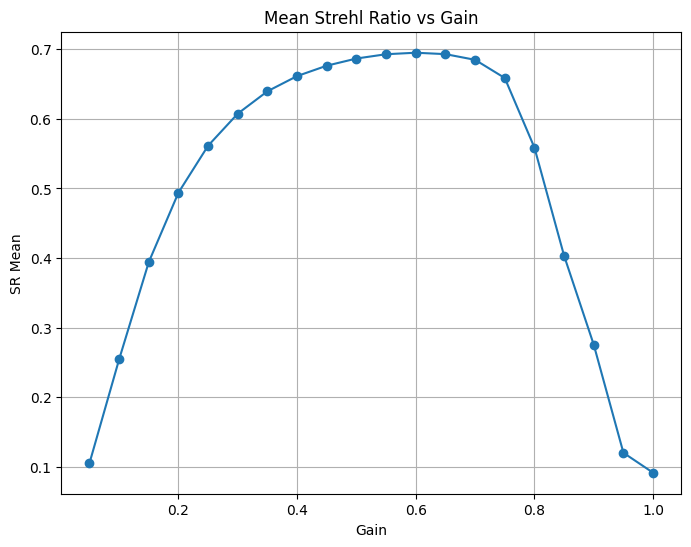

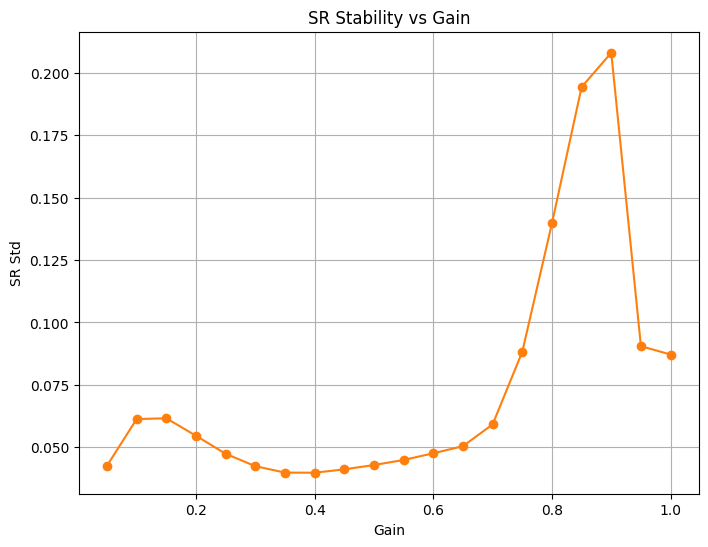

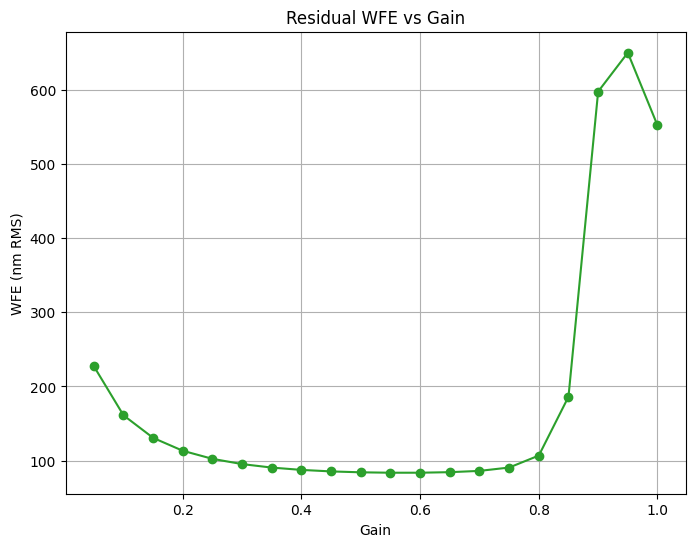

In [7]:
run_baseline(paramFile='2-2',frames=500)

In [ ]:
run_baseline(paramFile='2-3',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:19<02:35, 19.40s/it]

100/856
Time elapsed: 19.396236896514893 s


 22%|██▏       | 2/9 [00:38<02:12, 18.95s/it]

200/856
Time elapsed: 18.627798557281494 s


...

700/856
Time elapsed: 17.517300605773926 s


 89%|████████▉ | 8/9 [02:15<00:17, 17.02s/it]

800/856
Time elapsed: 18.329675436019897 s


100%|██████████| 9/9 [02:22<00:00, 15.86s/it]

900/856
Time elapsed: 6.9374401569366455 s


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:35<04:41, 35.13s/it]

100/856
Time elapsed: 35.1281259059906 s


 22%|██▏       | 2/9 [01:11<04:09, 35.64s/it]

200/856
Time elapsed: 35.98840689659119 s


...

 89%|████████▉ | 8/9 [04:09<00:28, 28.03s/it]

800/856
Time elapsed: 22.10365891456604 s


100%|██████████| 9/9 [04:18<00:00, 28.70s/it]

900/856
Time elapsed: 9.074923753738403 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.02713942527770996 s
ZZt.. : 18.88726544380188 s
ZXt.. : 0.907219648361206 s
XXt.. : 0.42241930961608887 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.05364632606506348 s
ZZt.. : 1.6689300537109375e-06 s
ZXt.. : 9.059906005859375e-05 s
XXt.. : 1.33514404296875e-05 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.02381443977355957 s
ZZt.. : 3.0994415283203125e-06 s
ZXt.. : 3.814697265625e-05 s
XXt.. : 7.62939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.1388,SR_std = 0.0273,WFE = 198.59
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.3445,SR_std = 0.0535,WFE = 136.97
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.4859,SR_std = 0.0439,WFE = 110.97
Runn

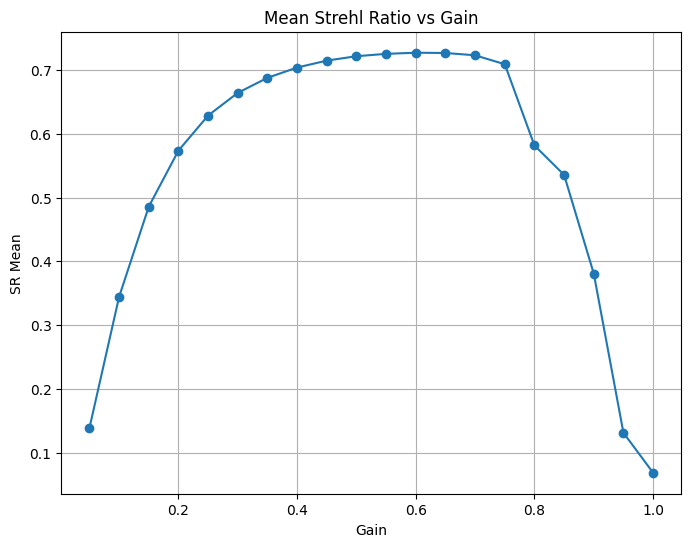

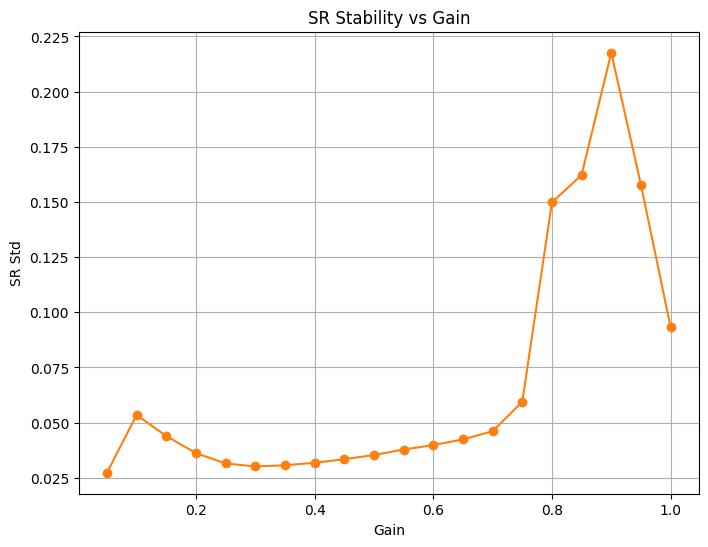

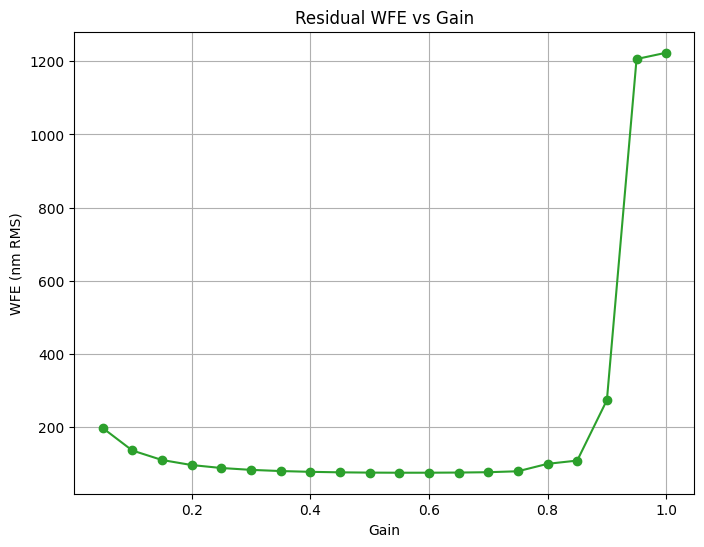

In [3]:
run_baseline(paramFile='3-1',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:32<04:21, 32.71s/it]

100/856
Time elapsed: 32.707823276519775 s


 22%|██▏       | 2/9 [00:57<03:18, 28.31s/it]

200/856
Time elapsed: 25.23125720024109 s


...

 89%|████████▉ | 8/9 [02:52<00:18, 18.87s/it]

800/856
Time elapsed: 16.63979721069336 s


100%|██████████| 9/9 [03:00<00:00, 20.03s/it]

900/856
Time elapsed: 7.450100898742676 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.04842352867126465 s
ZZt.. : 22.07497763633728 s
ZXt.. : 1.125565767288208 s
XXt.. : 0.5578186511993408 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.023073673248291016 s
ZZt.. : 7.152557373046875e-07 s
ZXt.. : 5.435943603515625e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.023955106735229492 s
ZZt.. : 9.5367431640625e-07 s
ZXt.. : 3.7670135498046875e-05 s
XXt.. : 8.344650268554688e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.1796,SR_std = 0.0623,WFE = 207.95
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.3660,SR_std = 0.0627,WFE = 143.89
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.5065,SR_std = 0.0523,WFE = 117.1

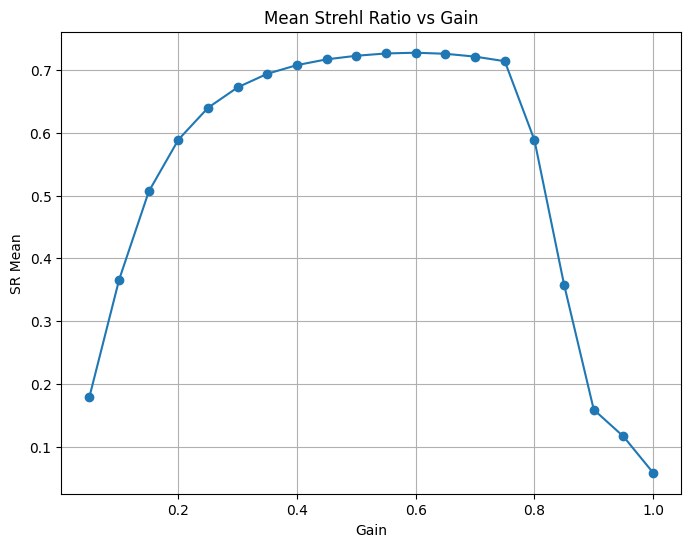

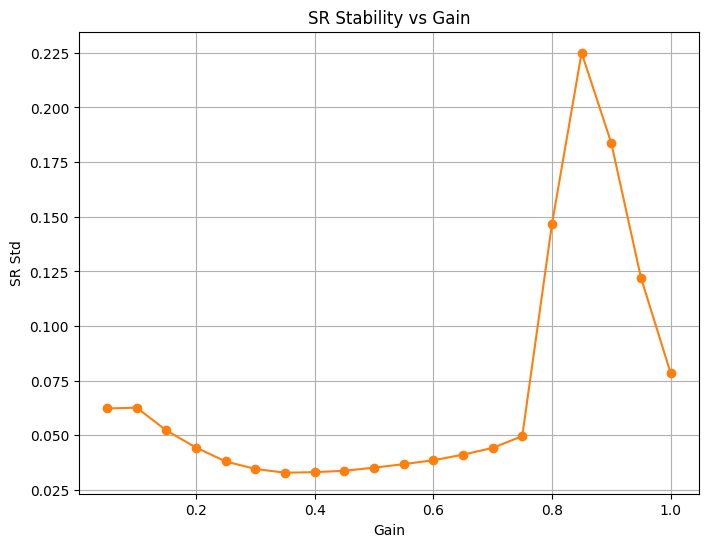

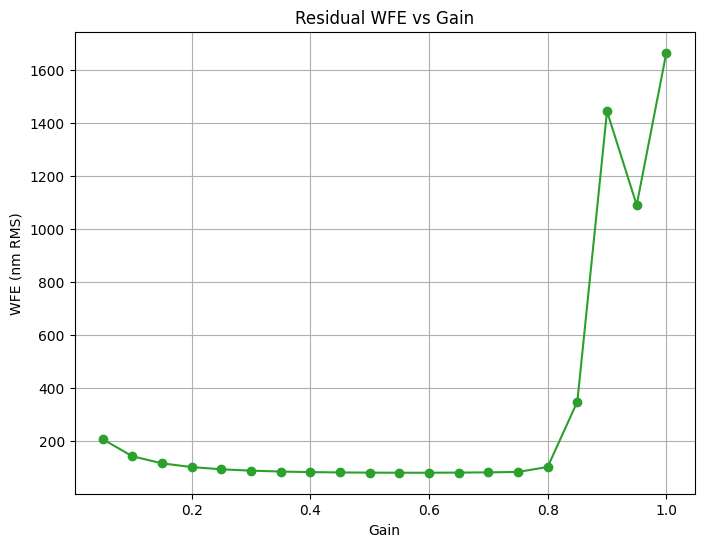

In [4]:
run_baseline(paramFile='3-2',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:25<03:27, 25.89s/it]

100/856
Time elapsed: 25.88684105873108 s


 22%|██▏       | 2/9 [00:48<02:48, 24.12s/it]

200/856
Time elapsed: 22.886300802230835 s


...

 89%|████████▉ | 8/9 [02:33<00:17, 17.46s/it]

800/856
Time elapsed: 17.212839126586914 s


100%|██████████| 9/9 [02:40<00:00, 17.80s/it]

900/856
Time elapsed: 6.873744487762451 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.05147290229797363 s
ZZt.. : 24.047648668289185 s
ZXt.. : 0.6248776912689209 s
XXt.. : 0.3176877498626709 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.025259017944335938 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 5.817413330078125e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.030828237533569336 s
ZZt.. : 1.6689300537109375e-06 s
ZXt.. : 5.269050598144531e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.1496,SR_std = 0.0476,WFE = 218.52
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.3576,SR_std = 0.0470,WFE = 145.58
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.4990,SR_std = 0.0395,WFE = 11

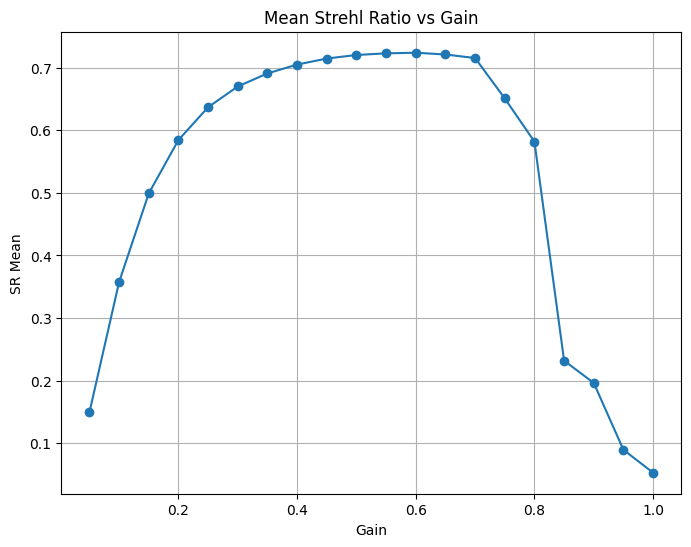

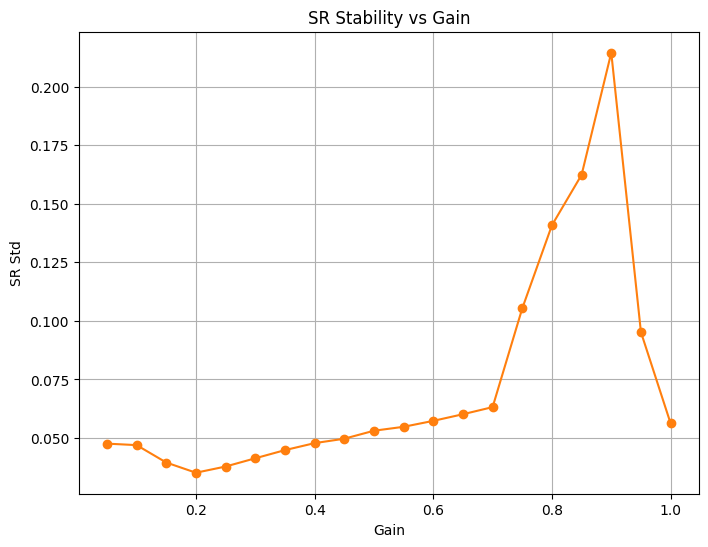

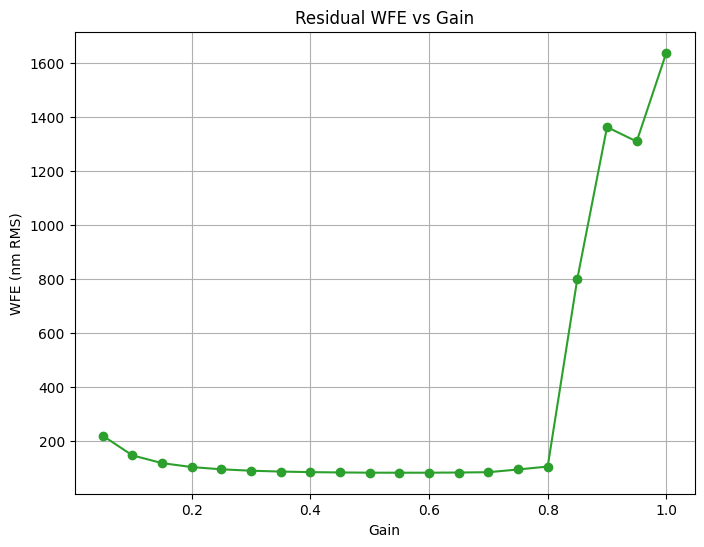

In [5]:
run_baseline(paramFile='3-3',frames=500)

In [2]:
param = load_parameter_file('paramFile3')
param['samplingRate'] = 1000
param['exposureTime'] = 1
param['clockRate'] = 1000
tel = Telescope(resolution         =   param['resolution'], 
                    diameter           =   param['diameter'], 
                    samplingTime       =   1/param['samplingRate'], 
                    centralObstruction =   param['centralObstruction'])

ngs = Source(magnitude             =   param['magnitude'],
                    optBand               =   param['opticalBand'])
ngs * tel
atm = Atmosphere(telescope         =   tel, 
                        r0                =   param['r0'], 
                        L0                =   param['L0'], 
                        windSpeed         =   param['windSpeed'],
                        fractionalR0      =   param['fractionnalR0'], 
                        windDirection     =   param['windDirection'],
                        altitude          =   param['altitude'])

dm = DeformableMirror(telescope    =   tel, 
                            nSubap       =   param['nSubap'], 
                            mechCoupling =   param['mechCoupling'])

wfs = ShackHartmann(nSubap         =   param['nSubap'], 
                            telescope      =   tel, 
                            lightRatio     =   param['lightRatio'], 
                            is_geometric   =   param['is_geometric'], 
                            threshold_cog  =   param['threshold_cog'])


camH = Imager(exposure_time=param['exposureTime'], 
                    clock_rate=param['clockRate'],
                    nyquist_sampling=param['nyquist_sampling'],
                    field_stop_size=param['field_stop_size'])
wfs.cam.photonNoise                =   param['photonNoise']
wfs.cam.readoutNoise               =   param['readoutNoise']
wfs.cam.darkCurrent                =   param['darkCurrent']
ao_calib = ao_calibration(param=param, \
                            ngs=ngs, \
                            tel=tel, \
                            atm=atm, \
                            dm=dm, \
                            wfs=wfs, \
                            nameFolderIntMat=None, \
                            nameIntMat=None, \
                            nameFolderBasis=None, \
                            nameBasis=None, \
                            nMeasurements=100)
calib_CL = ao_calib.calib  # 交互矩阵
M2C_CL = ao_calib.M2C


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304.3
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates load

 25%|██▌       | 1/4 [00:03<00:09,  3.28s/it]

100/357
Time elapsed: 3.2758965492248535 s


 50%|█████     | 2/4 [00:06<00:05,  2.99s/it]

200/357
Time elapsed: 2.783261299133301 s


 75%|███████▌  | 3/4 [00:08<00:02,  2.90s/it]

300/357
Time elapsed: 2.7887678146362305 s


100%|██████████| 4/4 [00:10<00:00,  2.62s/it]

400/357
Time elapsed: 1.6178319454193115 s


No Modal Gains found. All gains set to 1


In [15]:
import random
def run(frames=10):
    atm.initializeAtmosphere(telescope=tel)
    dm.coefs = 0
    calib_CL    = ao_calib.calib # 交互矩阵
    M2C_CL      = ao_calib.M2C 

    tel+atm
    ngs*tel*dm*wfs
    gainCL=0.5
    actual_SR  = np.zeros(frames)
    SR_old = np.zeros(frames)
    residual = np.zeros(frames)
    dm.coefs = 0
    wfsSignal = np.zeros(wfs.nSignal)
    for current_step in range(frames):
        
        # gainCL = 0.6
        # 更新大气湍流相位屏
        atm.update()
        tel-atm
        camH.relay(tel.src)
        camH.reference_frame = camH.frame
        tel+atm

        # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 波前传感器
        tel * dm * wfs

        
        # # 存入队列
        # wfs_buffer.append(wfsSignal)

        # # 取出延迟后的信号
        # delayed_signal = wfs_buffer[0]
        # # 更新变形镜控制信号
        # dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ delayed_signal
        dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ wfsSignal
        wfsSignal = wfs.signal.copy()

        camH.relay(tel.src)
        SR_old[current_step]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))
        # 计算斯特列尔比（基于科学相机的PSF）
        actual_SR[current_step] = camH.strehl
        residual[current_step]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
        print("step:{} ---  SR:{:.4f} ----SR_old:{:.4f}----WFE:{:.1f}-----gain:{}".
              format(current_step,camH.strehl,SR_old[current_step],residual[current_step],gainCL))
    print("平均SR:{:.4f}".format(np.mean(actual_SR)))
    plt.title("avg_SR:{:.4f}--std:{:.4f}".format(np.mean(actual_SR),np.std(actual_SR[9:])))
    plt.plot(actual_SR,label='SR')
    plt.plot(SR_old,label='SR_old')

step:0 ---  SR:0.0624 ----SR_old:0.0002----WFE:772.9-----gain:0.5
step:1 ---  SR:0.0621 ----SR_old:0.0002----WFE:773.6-----gain:0.5
step:2 ---  SR:0.1748 ----SR_old:0.0541----WFE:449.6-----gain:0.5
step:3 ---  SR:0.7452 ----SR_old:0.6966----WFE:158.3-----gain:0.5
step:4 ---  SR:0.7400 ----SR_old:0.7374----WFE:145.3-----gain:0.5
step:5 ---  SR:0.7210 ----SR_old:0.7188----WFE:151.2-----gain:0.5
step:6 ---  SR:0.8079 ----SR_old:0.8032----WFE:123.2-----gain:0.5
step:7 ---  SR:0.7833 ----SR_old:0.7463----WFE:142.4-----gain:0.5
step:8 ---  SR:0.7233 ----SR_old:0.6672----WFE:167.4-----gain:0.5
step:9 ---  SR:0.7193 ----SR_old:0.6625----WFE:168.9-----gain:0.5
平均SR:0.5539


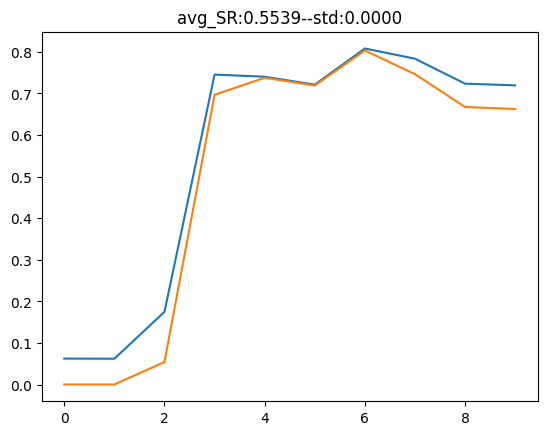

In [16]:
run(10)

In [6]:
atm.initializeAtmosphere(telescope=tel)

# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 10
# allocate memory to save data
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
SR_old                      = np.zeros(param['nLoop'])
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 1  # 传感增益

for i in range(param['nLoop']):
    a=time.time()

    atm.update()

    tel-atm
    camH.relay(tel.src)
    camH.reference_frame = camH.frame
    tel+atm
    # 记录总的波前误差
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    
    tel*dm*wfs

    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    
    wfsSignal=wfs.signal
    
    b= time.time()
    print('Elapsed time: ' + str(b-a) +' s')

    SR_old[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))  
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    camH.relay(tel.src)
    SR[i] = camH.strehl

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')

Elapsed time: 0.9795022010803223 s
Loop0/10 Turbulence: 772.8947459831028 -- Residual:772.8947459831028

Elapsed time: 0.9750392436981201 s
Loop1/10 Turbulence: 773.6216211083824 -- Residual:773.6216211083824

Elapsed time: 0.9901444911956787 s
Loop2/10 Turbulence: 774.3584543952883 -- Residual:158.9284186249703

Elapsed time: 0.9092702865600586 s
Loop3/10 Turbulence: 775.1150669351758 -- Residual:579.5527314186069

Elapsed time: 0.9048671722412109 s
Loop4/10 Turbulence: 775.9151956220711 -- Residual:600.5280016798051

Elapsed time: 0.9389975070953369 s
Loop5/10 Turbulence: 776.7150912551591 -- Residual:134.10249477357837

Elapsed time: 0.9153003692626953 s
Loop6/10 Turbulence: 777.4594580450279 -- Residual:680.8754996818848

Elapsed time: 0.9116940498352051 s
Loop7/10 Turbulence: 778.2202489369862 -- Residual:721.28127534991

Elapsed time: 0.9217889308929443 s
Loop8/10 Turbulence: 779.0131380137027 -- Residual:170.47171981285823

Elapsed time: 0.929955244064331 s
Loop9/10 Turbulence: 